# Attempt 1

In [10]:
import random
from collections import defaultdict
import numpy as np

This is a function to track stats for a cube night with 7 people. I make the following assumptions:
1. The length a match of Magic takes is normally distributed (mean = 40 minutes; standard deviation = 8 minutes). You can change this if you want (look at the 2nd line of the code).
2. Matches continue until everyone has played at least 3 matches. The remaining matches conclude and give us the final match time. This means some players are playing more than 3 matches.
3. Players will never play a match against someone they have previously played against. I don't have a completely systematic way to ensure this; therefore, I throw an error if the matchups end up sufficiently 'unresolvable'. If someone has interest, I can explain exactly what I mean by this. However, it only happens about 1/1000 times, so it shouldn't affect our results enough for us to care.

In [ ]:
def round_update(matches_played, x1, x2):
    round_time = random.gauss(mu=40, sigma=15) # Edit this if you want to change the Magic match-length distribution
    matches_played[x1].append(x2)
    matches_played[x2].append(x1)
    return matches_played, round_time
def print_info(ongoing_rounds, current_pairings, remaining_players):
    print(f"Ongoing round times: {ongoing_rounds}")
    print(f"Current round pairings: {current_pairings}")
    print(f"Currently unpaired: {remaining_players}")
    print("")
    return
def append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time):
    round_times.append(new_time)
    ongoing_rounds.append(new_time)
    pairings.append([p1,p2])
    current_pairings.append([p1,p2])
    return round_times, ongoing_rounds, pairings, current_pairings
def count_matches_played(matches_played):
    sum_matches = 0
    for matches in matches_played.values():
        sum_matches += len(matches)
    matches_played = sum_matches/2
    return matches_played
def cube_w_7():
    matches_played = defaultdict(list)
    round_times = []
    ongoing_rounds = []
    pairings = []
    current_pairings = []
    remaining_players = [1,2,3,4,5,6,7]
    random.shuffle(remaining_players)
    
    # Sets up round 1 (i.e. first 3 matches)
    for match in range(3):
        p1 = remaining_players.pop()
        p2 = remaining_players.pop()
        matches_played, round_time = round_update(matches_played, p1, p2)
        round_times.append(round_time)
        ongoing_rounds.append(round_time)
        pairings.append([p1,p2])
        current_pairings.append([p1,p2])
    #print_info(ongoing_rounds, current_pairings, remaining_players)
    
    fewest_matches = 0
    while fewest_matches < 3:
        time_to_finish = min(ongoing_rounds)
        next_to_finish = ongoing_rounds.index(time_to_finish)
        p1 = remaining_players.pop()
        
        if current_pairings[next_to_finish][0] not in matches_played[p1]:
            p2 = current_pairings[next_to_finish][0]
            p2_finish_time = time_to_finish
            remaining_players.append(current_pairings[next_to_finish][1])
            matches_played, round_time = round_update(matches_played, p1, p2)
            ongoing_rounds.pop(next_to_finish)
            current_pairings.pop(next_to_finish)
            new_time = round_time + time_to_finish
            round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
            #print_info(ongoing_rounds, current_pairings, remaining_players)
        elif current_pairings[next_to_finish][1] not in matches_played[p1]:
            p2 = current_pairings[next_to_finish][1]
            remaining_players.append(current_pairings[next_to_finish][0])
            matches_played, round_time = round_update(matches_played, p1, p2)
            ongoing_rounds.pop(next_to_finish)
            current_pairings.pop(next_to_finish)
            new_time = round_time + time_to_finish
            round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
            #print_info(ongoing_rounds, current_pairings, remaining_players)
        else:
            waiting_ppl = current_pairings.pop(next_to_finish)
            waiting_round_end = ongoing_rounds.pop(next_to_finish)
            remaining_players.extend(waiting_ppl)
            
            time_to_finish = min(ongoing_rounds)
            next_to_finish = ongoing_rounds.index(time_to_finish)
            if current_pairings[next_to_finish][0] not in matches_played[p1]:
                p2 = current_pairings[next_to_finish][0]
                remaining_players.append(current_pairings[next_to_finish][1])
                matches_played, round_time = round_update(matches_played, p1, p2)
                ongoing_rounds.pop(next_to_finish)
                current_pairings.pop(next_to_finish)
                new_time = round_time + time_to_finish
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)        
            elif current_pairings[next_to_finish][1] not in matches_played[p1]:
                p2 = current_pairings[next_to_finish][1]
                remaining_players.append(current_pairings[next_to_finish][0])
                matches_played, round_time = round_update(matches_played, p1, p2)
                ongoing_rounds.pop(next_to_finish)
                current_pairings.pop(next_to_finish)
                new_time = round_time + time_to_finish
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)
            else:
                if fewest_matches >= 3:
                    final_time = max(round_times)
                    number_of_matches = count_matches_played(matches_played)
                    return final_time, number_of_matches
                raise TypeError("Unable to create new matchup 1")
    
            p1 = remaining_players.pop()
            if remaining_players[0] not in matches_played[p1]:
                p2 = remaining_players.pop(0)
                matches_played, round_time = round_update(matches_played, p1, p2)
                new_time = round_time + waiting_round_end
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)        
            elif remaining_players[1] not in matches_played[p1]:
                p2 = remaining_players.pop(1)
                matches_played, round_time = round_update(matches_played, p1, p2)
                new_time = round_time + waiting_round_end
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)
            else:
                if fewest_matches >= 3:
                    final_time = max(round_times)
                    return final_time, number_of_matches                
                raise TypeError("Unable to create new matchup 2")
    
        player_w_least_matches = min(matches_played.values(), key=len)
        fewest_matches = len(player_w_least_matches)
        
    #print(f"Matches played: {dict(matches_played)}")
    #print(f"Round times: {round_times}")
    #print(f"All round pairings: {pairings}")
    final_time = max(round_times)
    number_of_matches = count_matches_played(matches_played)
    return final_time, number_of_matches

Here is a simulation of 10,000 cube nights with 7 players. I added succussful trials to show that the failure rate is in-fact <1/1000. 

Since people are playing more than 3 matches on average, we account for this by looking at how many matches (on average) a person can complete in 150 minutes. For the set of all game nights $A$, the calculation is:
$$\sum_{i \in A}\frac{2*(\text{number of matches})_i}{(\text{number of players})}*\frac{(150\text{ min})}{(\text{final match time})_i} = \frac{300}{7}\sum_{i \in A}\frac{(\text{number of matches})_i}{(\text{final match time})_i}$$
The multiplication by 2 is because each match consists of 2 people.

In [10]:
final_times_7 = []
number_matches_7 = []
wait_times_7 = []
for _ in range(10000):
    try:
        final_time, number_of_matches = cube_w_7()
        wait_times_7.append(number_of_matches/final_time)
        final_times_7.append(final_time)
        number_matches_7.append(number_of_matches)
    except:
        pass
print(f"Successfull trials: {len(final_times_7)}")
print(f"Average time for the last match to finish: {np.mean(final_times_7)}")
print(f"Average number of matches completed per-person in 150 minutes: {np.mean(wait_times_7)*300/7}")
print(np.mean(number_matches_7))

Successfull trials: 9925
Average time for the last match to finish: 174.84575833405285
Average number of matches completed per-person in 150 minutes: 2.9473874545009404
11.876675062972293


Here is the code for the 8 player cube night, for comparison.

In [38]:
def cube_w_8(mu = 40, sigma = 15):
    final_time = 0
    waiting_time = 0
    for match in range(3):
        r1 = random.gauss(mu=mu, sigma=sigma)
        r2 = random.gauss(mu=mu, sigma=sigma)
        r3 = random.gauss(mu=mu, sigma=sigma)
        r4 = random.gauss(mu=mu, sigma=sigma)
        round_time = max([r1, r2, r3, r4])
        final_time += round_time
        if match != 2:
            waiting_time += 2*(round_time - r1) + 2*(round_time - r2) + 2*(round_time - r3) + 2*(round_time - r4)
    return final_time, waiting_time

The calculation for averagte matches per-person in 150 minutes is simpler here (since there are always 12 matches played):
$$\frac{150*12*2}{8*(\text{avg final time})} $$


In [40]:
final_times_8 = []
waiting_times_8 = []
for _ in range(10000):
    final_time, waiting_time = cube_w_8()
    final_times_8.append(final_time)
    waiting_times_8.append(waiting_time)
mean_final = np.mean(final_times_8)
print(f"Average time for the last match to finish: {mean_final}")
print(f"Average idle time per night: {np.mean(waiting_times_8)}")
print(f"Average number of matches completed per-person in 150 minutes: {2*12*150/mean_final/8}")

Average time for the last match to finish: 166.1320184893417
Average idle time per night: 245.7085513351976
Average number of matches completed per-person in 150 minutes: 2.708689174380133


In conclusion, it seems like matches are being more efficiently played with 8 people, even with all the added waiting times. I played around with the distribution choices a little, but it didn't seem to change that result.

There are issues with 'average downtime per player' (as Andy suggested). Without everyone having at least 3 rounds instead of exactly 3 rounds, the 7 person-pod will have extra wait time added on. We could stop counting wait time once people hit 3 rounds, but what if someone with 3 rounds waits for a while and then plays someone with 2 rounds? This doesn't seem right. What I ended up doing was counting wait time as no longer accruing if someone does not play any more mathces. 

Note: it is a mathematical certainty that someone must play 4 rounds in order for everyone to play at least 3 rounds.

# Attempt 2

Main updates to work on:
1. Clear up metrics confusion
2. Create graph showing how changes in mean/std change results
3. Have an individual-level distribution for each individual
4. Change to 'round-based' so things don't get too out of whack (like Dom proposed)

In [17]:
def round_update(matches_played, x1, x2):
    round_time = random.gauss(mu=40, sigma=15) # Edit this if you want to change the Magic match-length distribution
    matches_played[x1].append(x2)
    matches_played[x2].append(x1)
    return matches_played, round_time
def print_info(ongoing_rounds, current_pairings, remaining_players):
    print(f"Ongoing round times: {ongoing_rounds}")
    print(f"Current round pairings: {current_pairings}")
    print(f"Currently unpaired: {remaining_players}")
    print("")
    return
def append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time):
    round_times.append(new_time)
    ongoing_rounds.append(new_time)
    pairings.append([p1,p2])
    current_pairings.append([p1,p2])
    return round_times, ongoing_rounds, pairings, current_pairings
def count_matches_played(matches_played):
    sum_matches = 0
    for matches in matches_played.values():
        sum_matches += len(matches)
    matches_played = sum_matches/2
    return matches_played
def cube_w_7():
    matches_played = defaultdict(list)
    round_times = []
    ongoing_rounds = []
    pairings = []
    current_pairings = []
    remaining_players = [1,2,3,4,5,6,7]
    random.shuffle(remaining_players)
    count = 0
    
    # Sets up round 1 (i.e. first 3 matches)
    for match in range(3):
        p1 = remaining_players.pop()
        p2 = remaining_players.pop()
        matches_played, round_time = round_update(matches_played, p1, p2)
        round_times, ongoing_rounds, pairings, current_pairings = append_info(
            round_times, ongoing_rounds, pairings, current_pairings, p1, p2, round_time)
    #print_info(ongoing_rounds, current_pairings, remaining_players)
    
    fewest_matches = 0
    while fewest_matches < 3:
        time_to_finish = min(ongoing_rounds)
        next_to_finish = ongoing_rounds.index(time_to_finish)
        p1 = remaining_players.pop()
        
        # Check which of the two finishing players has less matches played
        if len(matches_played[current_pairings[next_to_finish][0]]) < len(matches_played[current_pairings[next_to_finish][1]]):
            preferred_opponent = current_pairings[next_to_finish][0]
            other_opponent = current_pairings[next_to_finish][1]
        else:
            preferred_opponent = current_pairings[next_to_finish][1]
            other_opponent = current_pairings[next_to_finish][0]

        # Try to match with preferred opponent first, then the other opponent (rematch avoidance)
        if preferred_opponent not in matches_played[p1]:
            p2 = preferred_opponent
            remaining_players.append(other_opponent)
            matches_played, round_time = round_update(matches_played, p1, p2)
            ongoing_rounds.pop(next_to_finish)
            current_pairings.pop(next_to_finish)
            new_time = round_time + time_to_finish
            round_times, ongoing_rounds, pairings, current_pairings = append_info(
                round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
            #print_info(ongoing_rounds, current_pairings, remaining_players)
        elif other_opponent not in matches_played[p1]:
            p2 = other_opponent
            remaining_players.append(preferred_opponent)
            matches_played, round_time = round_update(matches_played, p1, p2)
            ongoing_rounds.pop(next_to_finish)
            current_pairings.pop(next_to_finish)
            new_time = round_time + time_to_finish
            round_times, ongoing_rounds, pairings, current_pairings = append_info(
                round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
            #print_info(ongoing_rounds, current_pairings, remaining_players)
        # If both opponents would result in a rematch, we have to wait for another match to finish
        else:
            count += 1
            waiting_ppl = current_pairings.pop(next_to_finish)
            waiting_round_end = ongoing_rounds.pop(next_to_finish)
            remaining_players.extend(waiting_ppl)
            
            time_to_finish = min(ongoing_rounds)
            next_to_finish = ongoing_rounds.index(time_to_finish)
            if current_pairings[next_to_finish][0] not in matches_played[p1]:
                p2 = current_pairings[next_to_finish][0]
                remaining_players.append(current_pairings[next_to_finish][1])
                matches_played, round_time = round_update(matches_played, p1, p2)
                ongoing_rounds.pop(next_to_finish)
                current_pairings.pop(next_to_finish)
                new_time = round_time + time_to_finish
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)        
            elif current_pairings[next_to_finish][1] not in matches_played[p1]:
                p2 = current_pairings[next_to_finish][1]
                remaining_players.append(current_pairings[next_to_finish][0])
                matches_played, round_time = round_update(matches_played, p1, p2)
                ongoing_rounds.pop(next_to_finish)
                current_pairings.pop(next_to_finish)
                new_time = round_time + time_to_finish
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)
            else:
                if fewest_matches >= 3:
                    final_time = max(round_times)
                    number_of_matches = count_matches_played(matches_played)
                    return final_time, number_of_matches
                raise TypeError("Unable to create new matchup 1")
    
            p1 = remaining_players.pop()
            if remaining_players[0] not in matches_played[p1]:
                p2 = remaining_players.pop(0)
                matches_played, round_time = round_update(matches_played, p1, p2)
                new_time = round_time + waiting_round_end
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)        
            elif remaining_players[1] not in matches_played[p1]:
                p2 = remaining_players.pop(1)
                matches_played, round_time = round_update(matches_played, p1, p2)
                new_time = round_time + waiting_round_end
                round_times, ongoing_rounds, pairings, current_pairings = append_info(round_times, ongoing_rounds, pairings, current_pairings, p1, p2, new_time)
                #print_info(ongoing_rounds, current_pairings, remaining_players)
            else:
                if fewest_matches >= 3:
                    final_time = max(round_times)
                    return final_time, number_of_matches                
                raise TypeError("Unable to create new matchup 2")
    
        player_w_least_matches = min(matches_played.values(), key=len)
        fewest_matches = len(player_w_least_matches)
        
    #print(f"Matches played: {dict(matches_played)}")
    #print(f"Round times: {round_times}")
    #print(f"All round pairings: {pairings}")
    final_time = max(round_times)
    number_of_matches = count_matches_played(matches_played)
    return count

count = 0
i= 100
for _ in range(i):
    count += cube_w_7()
print(count/i)

TypeError: Unable to create new matchup 2

# Attempt 3

In [2]:
import random
import heapq
import numpy as np

def cube_w_7(mu=40.0, sigma=12.5, target_matches=3, seed=None, verbose=False):
    """
    Simulate the 7-player system you described.

    Returns a dict with:
      - total_time: time when the last match finishes
      - time_all_three: time when everyone has played at least `target_matches`
      - total_idle_time: sum of idle times over all players
      - idle_time_per_player: dict[player] -> idle time
      - matches_per_player: dict[player] -> number of matches played
      - time_of_third: dict[player] -> time they finished their 3rd match
      - opponents: dict[player] -> set of players they faced
    """
    if seed is not None:
        random.seed(seed)

    # Players are labeled 1..7
    players = [1,2,3,4,5,6,7]

    # Who each player has already played
    opponents = {p: set() for p in players}
    matches_per_player = {p: 0 for p in players}
    time_of_third = {p: None for p in players}

    # Idle time accounting
    idle_time = {p: 0.0 for p in players}
    idle_since = {p: 0.0 for p in players}  # everyone idle at t=0

    # Current match id for each player (or None if idle)
    current_match = {p: None for p in players}

    # Event queue: (end_time, match_id, p1, p2, start_time)
    events = []
    match_id_counter = 0
    t = 0.0

    def sample_duration():
        """Draw a strictly positive match duration from N(mu, sigma^2)."""
        d = random.gauss(mu, sigma)
        while d <= 0:
            d = random.gauss(mu, sigma)
        return d

    def start_match(p1, p2, current_time):
        """Start a match between p1 and p2 at current_time."""
        nonlocal match_id_counter
        assert current_match[p1] is None and current_match[p2] is None

        # Close their idle intervals
        for p in (p1, p2):
            idle_time[p] += current_time - idle_since[p]
            idle_since[p] = None

        dur = sample_duration()
        end_time = current_time + dur

        mid = match_id_counter
        match_id_counter += 1

        current_match[p1] = current_match[p2] = mid
        heapq.heappush(events, (end_time, mid, p1, p2, current_time)) # TEMP: first item (end_time) is used for heap ordering, then second item (mid), etc.

        if verbose:
            print(f"t={current_time:.2f}: start match {mid} between P{p1} and P{p2}, "
                  f"ends at {end_time:.2f}")

        return mid, end_time

    # --- Initial random matching: 3 matches + 1 unpaired (7th player) ---
    perm = players[:]
    random.shuffle(perm)
    idle_players = set(players)

    # First 6 players become 3 random pairs
    for k in range(0, 6, 2):
        p1, p2 = perm[k], perm[k + 1]
        start_match(p1, p2, t)
        idle_players.discard(p1)
        idle_players.discard(p2)

    time_all_three = None
    MAX_CONCURRENT = 3
    stop_new_matches = False  # set to True once everyone has >= target_matches

    def schedule_from_idle(current_time, banned=None):
        """
        Try to start additional matches among idle players (not in `banned`).
        Banned players are priority players who cannot be validly matched with any idle players.
        Respects:
          - MAX_CONCURRENT
          - no repeat pairings
          - stop_new_matches flag
        Returns True if at least one match was started.
        """
        nonlocal idle_players
        if stop_new_matches:
            return False

        if banned is None:
            banned = set()

        started_any = False
        # Candidates: idle players who are allowed to be paired now
        candidates = [p for p in idle_players
                      if current_match[p] is None and p not in banned]
        random.shuffle(candidates)
        used = set()

        while len(events) < MAX_CONCURRENT:
            avail = [p for p in candidates if p not in used]
            if len(avail) < 2:
                break

            found_pair = False
            for i in range(len(avail)):
                a = avail[i]
                for j in range(i + 1, len(avail)):
                    b = avail[j]
                    if b in used:
                        continue
                    if b not in opponents[a]:  # no repeat pairing
                        start_match(a, b, current_time)
                        idle_players.discard(a)
                        idle_players.discard(b)
                        used.add(a)
                        used.add(b)
                        started_any = True
                        found_pair = True
                        break
                if found_pair:
                    break

            if not found_pair:
                break

        return started_any

    # --- Main event loop ---
    steps = 0
    while True:
        steps += 1

        # Termination: everyone has at least target_matches and no matches running
        if all(matches_per_player[p] >= target_matches for p in players) and not events:
            total_time = t
            break

        # If there are no matches running but we still need more matches, start from idle
        if not events:
            if verbose:
                print(f"t={t:.2f}: no active matches, scheduling from idle {idle_players}")
            made = schedule_from_idle(t)
            if not made:
                # No legal new matches exist
                total_time = t
                break
            else:
                continue

        # Pop the next finishing match
        end_time, mid, p1, p2, start_time = heapq.heappop(events)
        t = end_time
        if verbose:
            print(f"t={t:.2f}: end match {mid} between P{p1} and P{p2}")

        # Update match stats
        opponents[p1].add(p2)
        opponents[p2].add(p1)
        for p in (p1, p2):
            matches_per_player[p] += 1
            if matches_per_player[p] == target_matches:
                time_of_third[p] = t

        # Mark them idle
        idle_players.update([p1, p2])
        for p in (p1, p2):
            current_match[p] = None
            idle_since[p] = t

        # Check if we just reached "everyone has >= target_matches"
        if time_all_three is None and all(matches_per_player[p] >= target_matches for p in players):
            time_all_three = t
            stop_new_matches = True  # don't start *new* matches after this point

        # --- Scheduling after a match finishes ---

        # "7th unpaired player" = idle player who has been idle the longest
        idle_before = [p for p in idle_players if idle_since[p] < t]  # idle before this finish
        priority_player = min(idle_before, key=lambda p: idle_since[p]) if idle_before else None

        banned = set()

        # Step 1: try to match priority_player with one of the two who just finished
        # (prioritizing which of the two has played fewer matches)
        # (only if we are still allowed to start new matches)
        if priority_player is not None and not stop_new_matches:
            candidates = []
            for q in (p1, p2):
                if q != priority_player and q not in opponents[priority_player]:
                    if current_match[q] is None:
                        candidates.append(q)

            if candidates and len(events) < MAX_CONCURRENT:
                q = min(candidates, key=lambda p: matches_per_player[p])
                start_match(priority_player, q, t)
                idle_players.discard(priority_player)
                idle_players.discard(q)
            else:
                # They already played both finishers; they must wait for another finish,
                # so we don't use them in the generic pairing below.
                banned.add(priority_player)

        # Step 2: fill remaining slots with any other legal idle pairings
        if len(events) < MAX_CONCURRENT:
            schedule_from_idle(t, banned=banned)

        if steps > 10000:
            raise RuntimeError("Too many steps; something went wrong")

    # Close any final idle intervals up to total_time
    #for p in players:
    #    idle_time[p] += total_time - idle_since[p]
    # NOTE: By removing this, I am assuming that once people are done with their final match, they no longer have idle time

    return {
        "total_time": total_time,
        "time_all_three": time_all_three if time_all_three is not None else total_time,
        "total_idle_time": sum(idle_time.values()),
        "idle_time_per_player": idle_time,
        "matches_per_player": matches_per_player,
        "time_of_third": time_of_third,
        "opponents": opponents,
    }



if __name__ != "__main__":
    result = cube_w_7()

    print(f"Total time until last match finishes: {result['total_time']:.2f}")
    print(f"Time until everyone has ≥ 3 matches: {result['time_all_three']:.2f}")
    print(f"Total idle time over all players: {result['total_idle_time']:.2f}")
    print(f"Idle time per player: {result["idle_time_per_player"]}")
    print(f"Time each player completed match 3: {result['time_of_third']}")
    print("Matches per player:", result["matches_per_player"])


if __name__ == "__main__":
    
    total_time_list = []
    time_all_three_list = []
    total_idle_time_list = []
    idle_time_per_player_list = []
    time_of_third_list = []
    matches_per_player_list = []
    for _ in range(10000):
        result = cube_w_7()
        total_time_list.append(result['total_time'])
        time_all_three_list.append(result["time_all_three"])
        total_idle_time_list.append(result["total_idle_time"])
        time_of_third_list.append(result["time_of_third"])
        matches_per_player_list.append(result["matches_per_player"])

    print(f"Average total time until last match finishes: {np.mean(total_time_list)}")
    print(f"Average time until everyone has ≥ 3 matches: {np.mean(time_all_three_list)}")
    print(f"Average total idle time over all players: {np.mean(total_idle_time_list)}")
    print(f"Average idle time per player: {np.mean(total_idle_time_list)/7}")



Average total time until last match finishes: 199.10601543411497
Average time until everyone has ≥ 3 matches: 168.13091117348912
Average total idle time over all players: 159.37545211731526
Average idle time per player: 22.76792173104504


In [3]:
def cube_w_8(mu = 35, sigma = 12.5):
    final_time = 0
    idle_time = 0
    for match in range(3):
        r1 = random.gauss(mu=mu, sigma=sigma)
        r2 = random.gauss(mu=mu, sigma=sigma)
        r3 = random.gauss(mu=mu, sigma=sigma)
        r4 = random.gauss(mu=mu, sigma=sigma)
        round_time = max([r1, r2, r3, r4])
        final_time += round_time
        if match != 2:
            idle_time += 2*(round_time - r1) + 2*(round_time - r2) + 2*(round_time - r3) + 2*(round_time - r4)
    return final_time, idle_time

if __name__ != "__main__":
    final_time, idle_time = cube_w_8()
    print(f"Total time until last match finishes: {final_time}")
    print(f"Total idle time over all players: {idle_time}")

if __name__ == "__main__":
    final_times = []
    idle_times = []
    for _ in range(10000):
        final_time, idle_time = cube_w_8()
        final_times.append(final_time)
        idle_times.append(idle_time)
    print(f"Average time for the last match to finish: {np.mean(final_times)}")
    print(f"Average idle time per player: {np.mean(idle_times)/8}")
    

Average time for the last match to finish: 143.72367594394566
Average idle time per player: 25.81578445782991


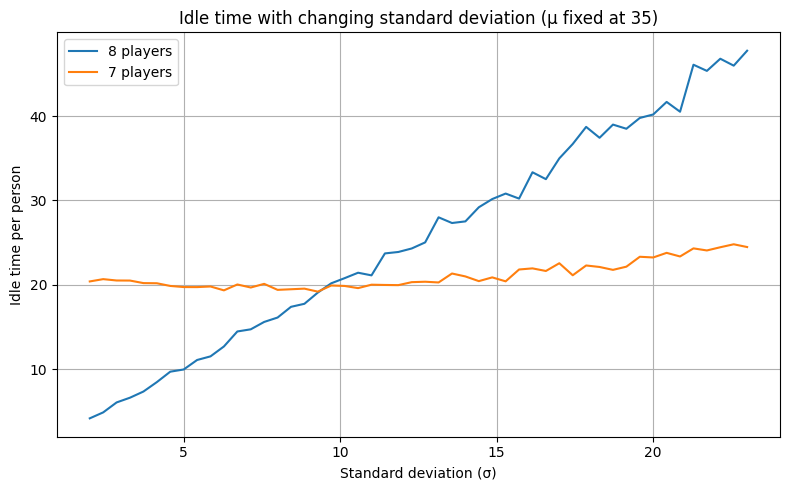

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Fixed mean and std-range to explore
# -----------------------------------------
mu_fixed = 35

# -------------------------------------------------
# 2. Wrapped functions as to only end up with the relevant info
# -------------------------------------------------
def eff_v1(mu, sigma):
    final_time, idle_time = cube_w_8(mu, sigma)
    return idle_time


def eff_v2(mu, sigma):
    results = cube_w_7(mu, sigma)
    return results['total_idle_time']

stds = np.linspace(2, 23, 50)  # range of std values to check

# Averaging over multiple runs
n_runs = 100

# -----------------------------------------
# 3. Evaluate both versions across stds
# -----------------------------------------
scores1 = []
scores2 = []

for sigma in stds:
    v1_vals = [eff_v1(mu_fixed, sigma)/8 for _ in range(n_runs)]
    v2_vals = [eff_v2(mu_fixed, sigma)/7 for _ in range(n_runs)]
    scores1.append(np.mean(v1_vals))
    scores2.append(np.mean(v2_vals))

scores1 = np.array(scores1)
scores2 = np.array(scores2)
diff = scores2 - scores1

# -----------------------------------------
# 4. Plot comparison
# -----------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(stds, scores1, label='8 players')
ax1.plot(stds, scores2, label='7 players')
ax1.set_xlabel("Standard deviation (σ)")
ax1.set_ylabel("Idle time per person")
ax1.set_title(f"Idle time with changing standard deviation (μ fixed at {mu_fixed})")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Fixed mean and std-range to explore
# -----------------------------------------
sigma_fixed = 12.5 

# -------------------------------------------------
# 2. Wrapped functions as to only end up with the relevant info
# -------------------------------------------------
def eff_v1(mu, sigma):
    final_time, idle_time = cube_w_8(mu, sigma)
    return idle_time


def eff_v2(mu, sigma):
    results = cube_w_7(mu, sigma)
    return results['total_idle_time']

mus = np.linspace(15, 50, 50)  # range of std values to check

# Averaging over multiple runs
n_runs = 100

# -----------------------------------------
# 3. Evaluate both versions across stds
# -----------------------------------------
scores1 = []
scores2 = []

for mu in mus:
    v1_vals = [eff_v1(mu, sigma_fixed)/8 for _ in range(n_runs)]
    v2_vals = [eff_v2(mu, sigma_fixed)/7 for _ in range(n_runs)]
    scores1.append(np.mean(v1_vals))
    scores2.append(np.mean(v2_vals))

scores1 = np.array(scores1)
scores2 = np.array(scores2)
diff = scores2 - scores1

# -----------------------------------------
# 4. Plot comparison
# -----------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(mus, scores1, label='8 players')
ax1.plot(mus, scores2, label='7 players')
ax1.set_xlabel("Mean (μ)")
ax1.set_ylabel("Idle time per person")
ax1.set_title(f"Idle time with changing mean (σ fixed at {sigma_fixed})")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()


NameError: name 'cube_w_8' is not defined

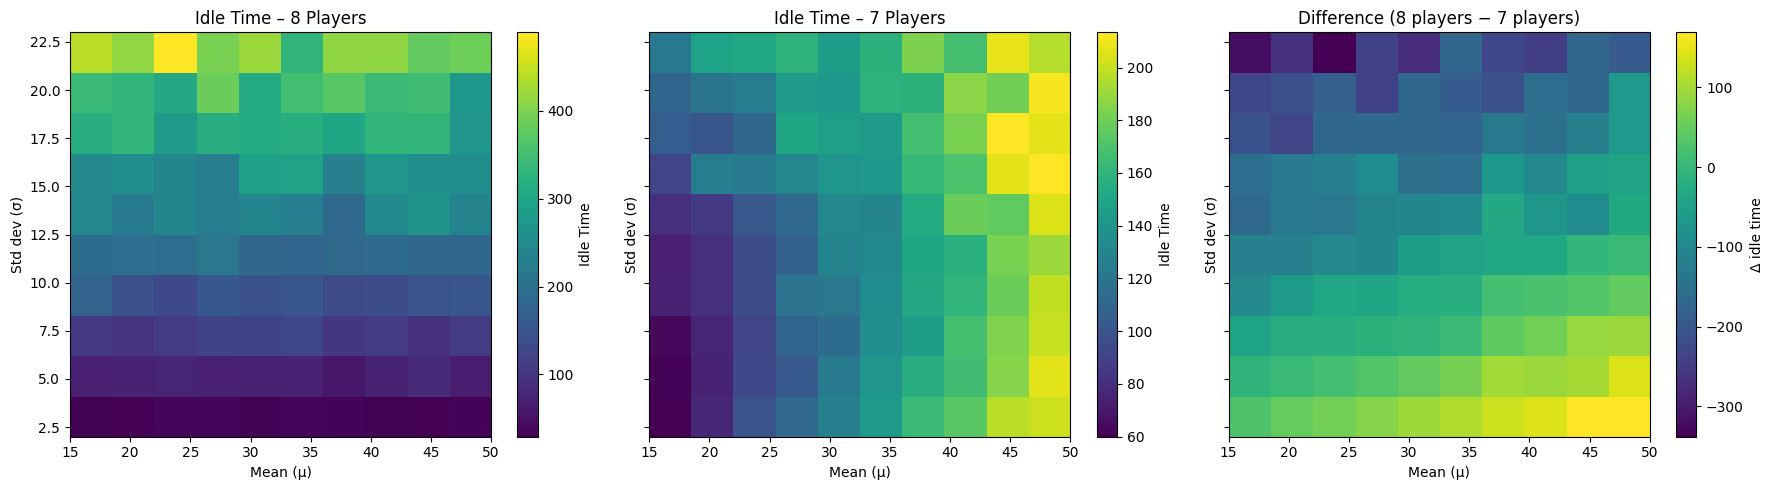

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def eff_v1(mu, sigma):
    final_time, idle_time = cube_w_8(mu, sigma)
    return idle_time


def eff_v2(mu, sigma):
    results = cube_w_7(mu, sigma)
    return results['total_idle_time']


# -------------------------------------------------
# 2. Helper to evaluate over a grid of (mean, std)
# -------------------------------------------------
def evaluate_on_grid(func, means, stds, n_runs=1):
    """
    Evaluate an efficiency function on a grid of (mu, sigma).
    If your function is stochastic, increase n_runs to average over repetitions.
    """
    scores = np.zeros((len(stds), len(means)))

    for i, sigma in enumerate(stds):
        for j, mu in enumerate(means):
            vals = [func(mu, sigma) for _ in range(n_runs)]
            scores[i, j] = np.mean(vals)
    return scores


# -------------------------------------------------
# 3. Choose the range of mean and std you care about
#    (edit these to match your problem)
# -------------------------------------------------
means = np.linspace(15, 50, 10)   # e.g. 20, 25, ..., 60
stds  = np.linspace(2, 23, 10)    # e.g. 5, 7.14, ..., 20

# If the functions are noisy simulations, set n_runs > 1 to average out noise
n_runs = 10

scores1 = evaluate_on_grid(eff_v1, means, stds, n_runs=n_runs)
scores2 = evaluate_on_grid(eff_v2, means, stds, n_runs=n_runs)
diff    = scores2 - scores1      # positive = v2 more efficient than v1


# -------------------------------------------------
# 4. Plot: two heatmaps + difference
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Common extent so x/y are in actual (mu, sigma) units
extent = [means.min(), means.max(), stds.min(), stds.max()]

im1 = axes[0].imshow(scores1, origin='lower', aspect='auto', extent=extent)
axes[0].set_title("Idle Time – 8 Players")
axes[0].set_xlabel("Mean (μ)")
axes[0].set_ylabel("Std dev (σ)")
fig.colorbar(im1, ax=axes[0], label="Idle Time")

im2 = axes[1].imshow(scores2, origin='lower', aspect='auto', extent=extent)
axes[1].set_title("Idle Time – 7 Players")
axes[1].set_xlabel("Mean (μ)")
axes[1].set_ylabel("Std dev (σ)")
fig.colorbar(im2, ax=axes[1], label="Idle Time")

im3 = axes[2].imshow(diff, origin='lower', aspect='auto', extent=extent)
axes[2].set_title("Difference (8 players − 7 players)")
axes[2].set_xlabel("Mean (μ)")
axes[2].set_ylabel("Std dev (σ)")
fig.colorbar(im3, ax=axes[2], label="Δ idle time")

plt.tight_layout()
plt.show()


Super interesting. Idle time in the 8 player draft increases as sigma does, but idle time in the 7 player draft increases as mu does.

# Attempt 4

The only thing I want to add here is individual-level distributions instead of an overall match distribution (hierarchical modeling???). This mimics slow players or people who are playing slow/controlling decks for the night. We can assume that sigma is constant, since people who tend to play at a certain pace will continue to do so with the same variation no matter what the pace is (maybe this is not quite true as mu tends towards 0). However, I would expect slow players to always lead to slow games (in which case summing or max of the two RVs) vs controlling/slow decks which can sometimes be quickly beaten down (so we would need the average of the RVs). I should just make this call though. Lets go with slow players.

I should also add drafting time as an extra factor!!! Someone suggested this on reddit.

In [131]:
import random
import heapq
import numpy as np

def cube_w_7(mu=20.0, sigma=10.0, sigma_p=5.0, target_matches=3, seed=None, verbose=False):
    """
    Simulate the 7-player system you described.

    Returns a dict with:
      - total_time: time when the last match finishes
      - time_all_three: time when everyone has played at least `target_matches`
      - total_idle_time: sum of idle times over all players
      - idle_time_per_player: dict[player] -> idle time
      - matches_per_player: dict[player] -> number of matches played
      - time_of_third: dict[player] -> time they finished their 3rd match
      - opponents: dict[player] -> set of players they faced
    """
    if seed is not None:
        random.seed(seed)

    # Players are labeled 1..7
    players = [1,2,3,4,5,6,7]
    
    # Each player has a speed factor
    player_speed = {p: random.gauss(mu, sigma_p) for p in players}

    # Who each player has already played
    opponents = {p: set() for p in players}
    matches_per_player = {p: 0 for p in players}
    time_of_third = {p: None for p in players}

    # Idle time accounting
    idle_time = {p: 0.0 for p in players}
    idle_since = {p: 0.0 for p in players}  # everyone idle at t=0

    # Current match id for each player (or None if idle)
    current_match = {p: None for p in players}

    # Event queue: (end_time, match_id, p1, p2, start_time)
    events = []
    match_id_counter = 0
    t = 0.0

    def sample_duration(p1, p2):
        """Draw a positive match duration from N(players_mu, sigma^2)."""
        d1 = max(random.gauss(player_speed[p1], sigma), 0)
        d2 = max(random.gauss(player_speed[p2], sigma), 0)
        d = d1 + d2
        return d

    def start_match(p1, p2, current_time):
        """Start a match between p1 and p2 at current_time."""
        nonlocal match_id_counter
        assert current_match[p1] is None and current_match[p2] is None

        # Close their idle intervals
        for p in (p1, p2):
            idle_time[p] += current_time - idle_since[p]
            idle_since[p] = None

        dur = sample_duration(p1, p2)
        end_time = current_time + dur

        mid = match_id_counter
        match_id_counter += 1

        current_match[p1] = current_match[p2] = mid
        heapq.heappush(events, (end_time, mid, p1, p2, current_time))

        if verbose:
            print(f"t={current_time:.2f}: start match {mid} between P{p1} and P{p2}, "
                  f"ends at {end_time:.2f}")

        return mid, end_time

    # --- Initial random matching: 3 matches + 1 unpaired (7th player) ---
    perm = players[:]
    random.shuffle(perm)
    idle_players = set(players)

    # First 6 players become 3 random pairs
    for k in range(0, 6, 2):
        p1, p2 = perm[k], perm[k + 1]
        start_match(p1, p2, t)
        idle_players.discard(p1)
        idle_players.discard(p2)

    time_all_three = None
    MAX_CONCURRENT = 3
    stop_new_matches = False  # set to True once everyone has >= target_matches

    def schedule_from_idle(current_time, banned=None):
        """
        Try to start additional matches among idle players (not in `banned`).
        Banned players are priority players who cannot be validly matched with any idle players.
        Respects:
          - MAX_CONCURRENT
          - no repeat pairings
          - stop_new_matches flag
        Returns True if at least one match was started.
        """
        nonlocal idle_players
        if stop_new_matches:
            return False

        if banned is None:
            banned = set()

        started_any = False
        # Candidates: idle players who are allowed to be paired now
        candidates = [p for p in idle_players
                      if current_match[p] is None and p not in banned]
        random.shuffle(candidates)
        used = set()

        while len(events) < MAX_CONCURRENT:
            avail = [p for p in candidates if p not in used]
            if len(avail) < 2:
                break

            found_pair = False
            for i in range(len(avail)):
                a = avail[i]
                for j in range(i + 1, len(avail)):
                    b = avail[j]
                    if b in used:
                        continue
                    if b not in opponents[a]:  # no repeat pairing
                        start_match(a, b, current_time)
                        idle_players.discard(a)
                        idle_players.discard(b)
                        used.add(a)
                        used.add(b)
                        started_any = True
                        found_pair = True
                        break
                if found_pair:
                    break

            if not found_pair:
                break

        return started_any

    # --- Main event loop ---
    steps = 0
    while True:
        steps += 1

        # Termination: everyone has at least target_matches and no matches running
        if all(matches_per_player[p] >= target_matches for p in players) and not events:
            total_time = t
            break

        # If there are no matches running but we still need more matches, start from idle
        if not events:
            if verbose:
                print(f"t={t:.2f}: no active matches, scheduling from idle {idle_players}")
            made = schedule_from_idle(t)
            if not made:
                # No legal new matches exist
                total_time = t
                break
            else:
                continue

        # Pop the next finishing match
        end_time, mid, p1, p2, start_time = heapq.heappop(events)
        t = end_time
        if verbose:
            print(f"t={t:.2f}: end match {mid} between P{p1} and P{p2}")

        # Update match stats
        opponents[p1].add(p2)
        opponents[p2].add(p1)
        for p in (p1, p2):
            matches_per_player[p] += 1
            if matches_per_player[p] == target_matches:
                time_of_third[p] = t

        # Mark them idle
        idle_players.update([p1, p2])
        for p in (p1, p2):
            current_match[p] = None
            idle_since[p] = t

        # Check if we just reached "everyone has >= target_matches"
        if time_all_three is None and all(matches_per_player[p] >= target_matches for p in players):
            time_all_three = t
            stop_new_matches = True  # don't start *new* matches after this point

        # --- Scheduling after a match finishes ---

        # "7th unpaired player" = idle player who has been idle the longest
        idle_before = [p for p in idle_players if idle_since[p] < t]  # idle before this finish
        priority_player = min(idle_before, key=lambda p: idle_since[p]) if idle_before else None

        banned = set()

        # Step 1: try to match priority_player with one of the two who just finished
        # (prioritizing which of the two has played fewer matches)
        # (only if we are still allowed to start new matches)
        if priority_player is not None and not stop_new_matches:
            candidates = []
            for q in (p1, p2):
                if q != priority_player and q not in opponents[priority_player]:
                    if current_match[q] is None:
                        candidates.append(q)

            if candidates and len(events) < MAX_CONCURRENT:
                q = min(candidates, key=lambda p: matches_per_player[p])
                start_match(priority_player, q, t)
                idle_players.discard(priority_player)
                idle_players.discard(q)
            else:
                # They already played both finishers; they must wait for another finish,
                # so we don't use them in the generic pairing below.
                banned.add(priority_player)

        # Step 2: fill remaining slots with any other legal idle pairings
        if len(events) < MAX_CONCURRENT:
            schedule_from_idle(t, banned=banned)

        if steps > 10000:
            raise RuntimeError("Too many steps; something went wrong")

    return {
        "total_time": total_time,
        "time_all_three": time_all_three if time_all_three is not None else total_time,
        "total_idle_time": sum(idle_time.values()),
        "idle_time_per_player": idle_time,
        "matches_per_player": matches_per_player,
        "time_of_third": time_of_third,
        "opponents": opponents,
    }



if __name__ == "__main__":
    result = cube_w_7()

    print(f"Total time until last match finishes: {result['total_time']:.2f}")
    print(f"Time until everyone has ≥ 3 matches: {result['time_all_three']:.2f}")
    print(f"Total idle time over all players: {result['total_idle_time']:.2f}")
    print(f"Idle time per player: {result["idle_time_per_player"]}")
    print(f"Time each player completed match 3: {result['time_of_third']}")
    print("Matches per player:", result["matches_per_player"])


if __name__ != "__main__":
    
    total_time_list = []
    time_all_three_list = []
    total_idle_time_list = []
    idle_time_per_player_list = []
    time_of_third_list = []
    matches_per_player_list = []
    for _ in range(1000):
        result = cube_w_7()
        total_time_list.append(result['total_time'])
        time_all_three_list.append(result["time_all_three"])
        total_idle_time_list.append(result["total_idle_time"])
        time_of_third_list.append(result["time_of_third"])
        matches_per_player_list.append(result["matches_per_player"])

    print(f"Average total time until last match finishes: {np.mean(total_time_list)}")
    print(f"Average time until everyone has ≥ 3 matches: {np.mean(time_all_three_list)}")
    print(f"Average total idle time over all players: {np.mean(total_idle_time_list)}")
    print(f"Average idle time per player: {np.mean(total_idle_time_list)}")



Total time until last match finishes: 207.69
Time until everyone has ≥ 3 matches: 181.53
Total idle time over all players: 213.98
Idle time per player: {1: 13.489547178694991, 2: 47.5255158116999, 3: 47.69697664769343, 4: 35.47172058779129, 5: 16.649652242674925, 6: 38.76114676949381, 7: 14.386775503106648}
Time each player completed match 3: {1: 122.46419847256605, 2: 84.50680616789668, 3: 118.80192109257587, 4: 181.53481254464054, 5: 181.53481254464054, 6: 79.17603855295016, 7: 122.46419847256605}
Matches per player: {1: 5, 2: 5, 3: 5, 4: 3, 5: 3, 6: 5, 7: 4}


In [ ]:
def cube_w_8(mu=20.0, sigma=10.0, sigma_p=5.0, seed=None):
    
    if seed is not None:
        random.seed(seed)
        
    final_time = 0
    idle_time = 0
    # Players are labeled 1 to 8
    players = [1,2,3,4,5,6,7,8]
    # Matchups - unique up to isomorphism
    matches = [[1,2], [3,4], [5,6], [7,8], [1,3], [2,4], [5,7], [6,8], [1,5], [2,6], [3,7], [4,8]]
    
    # Each player has a speed factor
    player_speed = {p: random.gauss(mu, sigma_p) for p in players}

    for round in range(0, 12, 4):
        matchups = matches[round:round+4]
        match_times = []
        
        # Simulate each match in the round
        for match in matchups:
            p1, p2 = match
            d1 = max(random.gauss(player_speed[p1], sigma), 0)
            d2 = max(random.gauss(player_speed[p2], sigma), 0)
            match_time = d1 + d2
            match_times.append(match_time)
        final_time += max(match_times)
        
        # Calculate idle time for players in this round (only if not the last round)
        if round != 8:
            idle_time += 2*(max(match_times) - match_times[0]) + 2*(max(match_times) - match_times[1]) +\
                         2*(max(match_times) - match_times[2]) + 2*(max(match_times) - match_times[3])
    return final_time, idle_time

if __name__ != "__main__":
    final_time, idle_time = cube_w_8()
    print(f"Total time until last match finishes: {final_time}")
    print(f"Total idle time over all players: {idle_time}")


Total time until last match finishes: 147.97738386516258
Total idle time over all players: 274.2547139542615


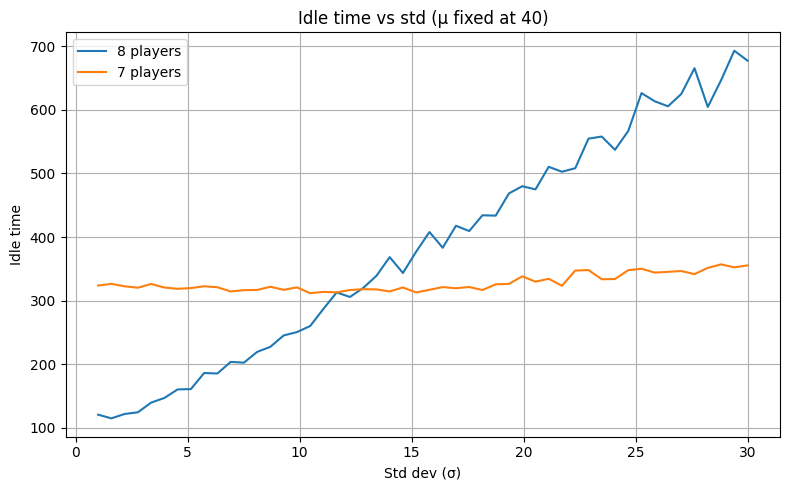

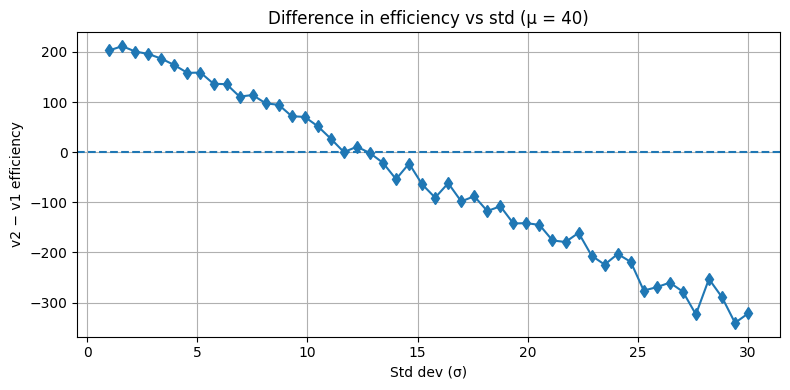

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Fixed mean and std-range to explore
# -----------------------------------------
mu_fixed = 40 

# -------------------------------------------------
# 2. Wrapped functions as to only end up with the relevant info
# -------------------------------------------------
def eff_v1(mu, sigma):
    final_time, idle_time = cube_w_8(mu, sigma)
    return idle_time


def eff_v2(mu, sigma):
    results = cube_w_7(mu, sigma)
    return results['total_idle_time']

stds = np.linspace(1, 30, 50)  # range of std values to check

# Averaging over multiple runs
n_runs = 100

# -----------------------------------------
# 3. Evaluate both versions across stds
# -----------------------------------------
scores1 = []
scores2 = []

for sigma in stds:
    v1_vals = [eff_v1(mu_fixed, sigma) for _ in range(n_runs)]
    v2_vals = [eff_v2(mu_fixed, sigma) for _ in range(n_runs)]
    scores1.append(np.mean(v1_vals))
    scores2.append(np.mean(v2_vals))

scores1 = np.array(scores1)
scores2 = np.array(scores2)
diff = scores2 - scores1

# -----------------------------------------
# 4. Plot comparison
# -----------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(stds, scores1, label='8 players')
ax1.plot(stds, scores2, label='7 players')
ax1.set_xlabel("Std dev (σ)")
ax1.set_ylabel("Idle time")
ax1.set_title(f"Idle time vs std (μ fixed at {mu_fixed})")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------------------
# 4. Optional: separate plot for the difference
# -----------------------------------------
fig, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(stds, diff, marker='d')
ax2.axhline(0, linestyle='--')
ax2.set_xlabel("Std dev (σ)")
ax2.set_ylabel("v2 − v1 efficiency")
ax2.set_title(f"Difference in efficiency vs std (μ = {mu_fixed})")
ax2.grid(True)

plt.tight_layout()
plt.show()


In [187]:
def drafting_time(players = 8, cards_in_pack = 15, packs = 3):
    final_time = 0
    for pack in range(packs):
        for card in range(cards_in_pack):
            pick_times = {p:0 for p in range(players)}
            for t in range(players):
                pick_times[t] += max(random.gauss(3*(cards_in_pack-card) + 3*pack, 7), 0)
            final_time += max(pick_times.values())
    final_minutes = final_time / 60
    return final_minutes
drafting_8 = []
drafting_7 = []
for _ in range(1000):
    drafting_8.append(drafting_time(players=8))
    drafting_7.append(drafting_time(players=7))
print(f"Average drafting time for 8 players: {np.mean(drafting_8)} minutes")
print(f"Average drafting time for 7 players: {np.mean(drafting_7)} minutes")

Average drafting time for 8 players: 27.719407750423684 minutes
Average drafting time for 7 players: 27.343070593842388 minutes
